# Equity Options Pricing — A Beginner's Guide

## What will you learn in this notebook?

This notebook is a complete introduction to **equity options** — what they are, how they are priced, what drives their value, and how volatility is at the heart of everything.

| Section | What you will learn |
|---|---|
| **1. Key Concepts** | Calls, puts, strike, expiry, premium, payoff, moneyness |
| **2. Black-Scholes Model** | The fundamental pricing formula and its intuition |
| **3. The Greeks** | Delta, Gamma, Vega, Theta — how option price reacts to market changes |
| **4. Volatility** | Historical vs implied vol, what the market is "pricing in" |
| **5. Volatility Smile** | Why real markets show a smile/skew and what it means |

---

## What is an equity option?

An **option** is a contract that gives the buyer the **right, but not the obligation**, to buy or sell a stock at a fixed price on (or before) a future date.

**Key terms:**

| Term | Meaning | Example |
|---|---|---|
| **Underlying (S)** | The stock the option is written on | Apple (AAPL) |
| **Strike (K)** | The price you can buy/sell at | $200 |
| **Expiry (T)** | When the option expires | 3 months from today |
| **Premium** | The price you pay to buy the option | $8 per share |
| **Call option** | Right to **buy** at the strike | Profit if stock rises above $200 |
| **Put option** | Right to **sell** at the strike | Profit if stock falls below $200 |
| **American option** | Can be exercised any time before expiry | Most stock options |
| **European option** | Can only be exercised at expiry | Index options, easier to price |

---

## Why do options exist?

| User | Why they use options |
|---|---|
| **Investor (hedger)** | Buy put to protect portfolio against a crash |
| **Trader (speculator)** | Buy call to bet on a stock rising, with limited downside (premium only) |
| **Market maker** | Quote both sides continuously, earn bid-ask spread |
| **CFO / corporate treasurer** | Hedge equity compensation or convertible bond exposure |

---

## The key insight: options have *asymmetric* payoffs

When you buy a call option for $8:
- If the stock stays below the strike → you lose $8 (the premium). That is your maximum loss.
- If the stock rises to $50 above the strike → you gain $50 − $8 = $42 per share.

This **asymmetry** (limited downside, unlimited upside) is what makes options valuable — and what makes pricing them non-trivial.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
RNG = np.random.default_rng(42)

# ── Black-Scholes pricing ──────────────────────────────────────────────────────
def bs_d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, T, r, sigma):
    return bs_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    if T <= 0:
        return max(K - S, 0.0)
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ── Implied volatility (bisection) ────────────────────────────────────────────
def implied_vol(market_price, S, K, T, r, option_type="call"):
    intrinsic = max(S - K, 0) if option_type == "call" else max(K - S, 0)
    if market_price <= intrinsic + 1e-6:
        return np.nan
    fn = (lambda v: bs_call(S, K, T, r, v) - market_price
          if option_type == "call"
          else bs_put(S, K, T, r, v) - market_price)
    try:
        return brentq(fn, 1e-6, 10.0)
    except ValueError:
        return np.nan

# ── Greeks ─────────────────────────────────────────────────────────────────────
def delta_call(S, K, T, r, sigma):
    return norm.cdf(bs_d1(S, K, T, r, sigma))

def delta_put(S, K, T, r, sigma):
    return norm.cdf(bs_d1(S, K, T, r, sigma)) - 1

def gamma(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def vega(S, K, T, r, sigma):          # per 1% move in vol
    d1 = bs_d1(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T) / 100

def theta_call(S, K, T, r, sigma):    # per calendar day
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    t = (- S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
         - r * K * np.exp(-r * T) * norm.cdf(d2))
    return t / 365

def theta_put(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    t = (- S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
         + r * K * np.exp(-r * T) * norm.cdf(-d2))
    return t / 365

print("✓ Black-Scholes functions loaded")

✓ Black-Scholes functions loaded


## 1. Option Payoffs — What You Get at Expiry

Before pricing options, we need to understand what they *pay* at expiry (when T = 0 and no time value remains).

### 1.1 Call option payoff

A **long call** pays the buyer:

$$\text{Payoff} = \max(S_T - K,\ 0)$$

- If the stock price $S_T$ is above the strike $K$ → you exercise and collect the difference
- If the stock price is below the strike → you do nothing (payoff = 0)

The option cost (premium) shifts the profit/loss line down.

### 1.2 Put option payoff

A **long put** pays the buyer:

$$\text{Payoff} = \max(K - S_T,\ 0)$$

- If the stock falls below the strike → you profit (you can "sell" at K even though market is lower)
- If the stock is above the strike → you do nothing

### 1.3 Short positions

When you **sell** (write) an option, you collect the premium upfront but take the opposite payoff:
- **Short call**: you profit if the stock stays below the strike (unlimited loss if stock rallies)
- **Short put**: you profit if the stock stays above the strike (large loss if stock crashes)

### 1.4 Moneyness

| Term | Condition | What it means |
|---|---|---|
| **In-the-money (ITM)** | Call: S > K  /  Put: S < K | Has intrinsic value |
| **At-the-money (ATM)** | S ≈ K | Strike equals current price |
| **Out-of-the-money (OTM)** | Call: S < K  /  Put: S > K | No intrinsic value; only time value |

**Intrinsic value** = the immediate exercise value = max(S−K, 0) for a call.
**Time value** = option premium − intrinsic value. It decays to zero as expiry approaches.

/var/folders/zn/8l1qxk_s2z12z2dtb7lgbsdm0000gn/T/ipykernel_64742/4034154275.py:34: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/usr/local/anaconda3/envs/qf/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


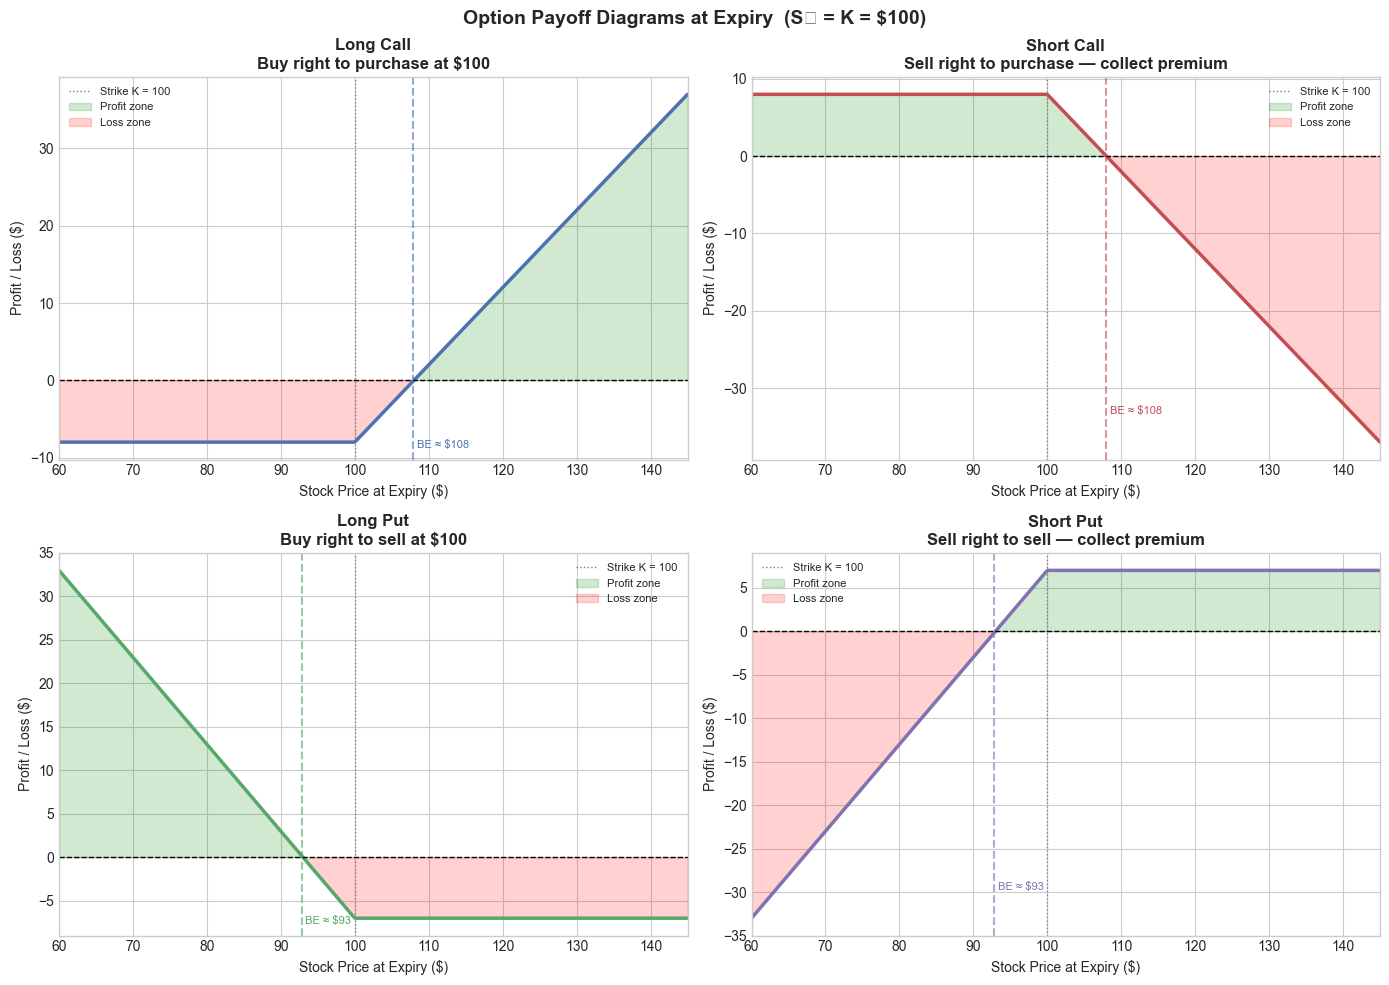

In [2]:
S0 = 100          # current stock price
K = 100           # strike price (at-the-money)
premium_call = 8  # option premium
premium_put = 7   # option premium
spot = np.linspace(60, 145, 400)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Option Payoff Diagrams at Expiry  (S = K = $100)", fontsize=14, fontweight="bold")

configs = [
    ("Long Call", np.maximum(spot - K, 0) - premium_call, "#4C72B0", "Buy right to purchase at $100"),
    ("Short Call", -(np.maximum(spot - K, 0)) + premium_call, "#C44E52", "Sell right to purchase — collect premium"),
    ("Long Put", np.maximum(K - spot, 0) - premium_put, "#55A868", "Buy right to sell at $100"),
    ("Short Put", -(np.maximum(K - spot, 0)) + premium_put, "#8172B2", "Sell right to sell — collect premium"),
]

for ax, (title, pnl, clr, desc) in zip(axes.flat, configs):
    ax.plot(spot, pnl, color=clr, linewidth=2.5)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.axvline(K, color="grey", linewidth=1, linestyle=":", label=f"Strike K = {K}")
    ax.fill_between(spot, pnl, 0, where=(pnl > 0), alpha=0.18, color="green", label="Profit zone")
    ax.fill_between(spot, pnl, 0, where=(pnl < 0), alpha=0.18, color="red", label="Loss zone")
    ax.set_title(f"{title}\n{desc}", fontweight="bold")
    ax.set_xlabel("Stock Price at Expiry ($)")
    ax.set_ylabel("Profit / Loss ($)")
    ax.set_xlim(60, 145)
    ax.legend(fontsize=8)
    # annotate breakeven
    breakevens = spot[np.where(np.diff(np.sign(pnl)))[0]]
    for be in breakevens:
        ax.axvline(be, color=clr, linewidth=1.5, linestyle="--", alpha=0.6)
        ax.text(be + 0.5, ax.get_ylim()[0] * 0.85, f"BE ≈ ${be:.0f}", fontsize=8, color=clr)

plt.tight_layout()
plt.show()

### How to read the payoff diagrams

Each chart shows **profit or loss** (y-axis) vs **stock price at expiry** (x-axis). The dotted vertical line marks the strike ($100).

**Long Call (top-left):**
- Below $100: flat at −$8 (you lose only the premium; you let the option expire)
- Above $108: you're in profit. The breakeven is strike + premium = $108
- The kink at $100 is where "no value → some value" switches on

**Short Call (top-right):**
- The mirror image of Long Call. You collected $8 upfront.
- If the stock closes below $100, you keep the full $8.
- If the stock rallies to $150, you face a large loss — this is the "unlimited risk" of selling naked calls

**Long Put (bottom-left):**
- Profit when the stock falls below $93 (strike − premium = $100 − $7)
- This is the classic **portfolio insurance** trade: you pay $7 to guarantee you can "sell" at $100 even if the stock crashes to $50

**Short Put (bottom-right):**
- You collected $7. You profit while the stock stays above $93.
- If the stock crashes (e.g., to $60), you face a loss of $100 − $60 − $7 = $33 per share

## 2. The Black-Scholes Model

### 2.1 The core question

If the payoff at expiry is simple to compute (max(S−K, 0)), why is pricing an option *before* expiry hard?

Because we don't know what the stock price will be at expiry. The stock moves randomly. We need to account for **all possible future stock paths** and price the option as the expected present value of the payoff.

### 2.2 The Black-Scholes assumptions

Black, Scholes, and Merton (1973) solved this by making the following assumptions:

| Assumption | What it means | Real-world caveat |
|---|---|---|
| **Log-normal stock prices** | Returns are normally distributed; prices can't go negative | Actual returns have fat tails and skew |
| **Constant volatility (σ)** | The vol doesn't change over time | Real vol changes constantly |
| **Continuous trading** | You can hedge continuously without friction | Real markets have gaps, spreads, discrete trading |
| **No dividends** | Stock pays no cash during the option's life | Extensions exist for dividends |
| **Risk-free rate (r) is constant** | Interest rates are fixed | Rates change |
| **No arbitrage** | Fair pricing prevents risk-free profits | Generally holds in liquid markets |

Despite these simplifications, Black-Scholes is the **industry standard** — not because it's perfect, but because it's a consistent, universal framework everyone can communicate with.

### 2.3 The Black-Scholes formula

For a **European call option**:

$$C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$

For a **European put option**:

$$P = K e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)$$

where:

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $N(\cdot)$ is the **cumulative normal distribution** (probability that a standard normal random variable is below the argument).

### 2.4 Intuition behind the formula

The call price has two terms:
- $S \cdot N(d_1)$: the expected stock price *if the option finishes in-the-money* × probability it does finish ITM (adjusted)
- $K e^{-rT} \cdot N(d_2)$: the discounted strike you pay × probability of exercise

$N(d_2)$ is the (risk-neutral) probability that the call will expire in-the-money. $N(d_1)$ is the **delta** of the call option (more on this in Section 3).

### 2.5 The five inputs

| Input | Symbol | Effect on call price | Effect on put price |
|---|---|---|---|
| **Stock price** | S | ↑ | ↓ |
| **Strike price** | K | ↓ | ↑ |
| **Time to expiry** | T | ↑ | ↑ |
| **Risk-free rate** | r | ↑ | ↓ |
| **Volatility** | σ | ↑ | ↑ |

**Volatility is the most important and most interesting input.** Unlike S, K, T, and r — which are either observable or fixed — volatility must be *estimated* or *implied* from market prices. This is the core challenge in options trading.

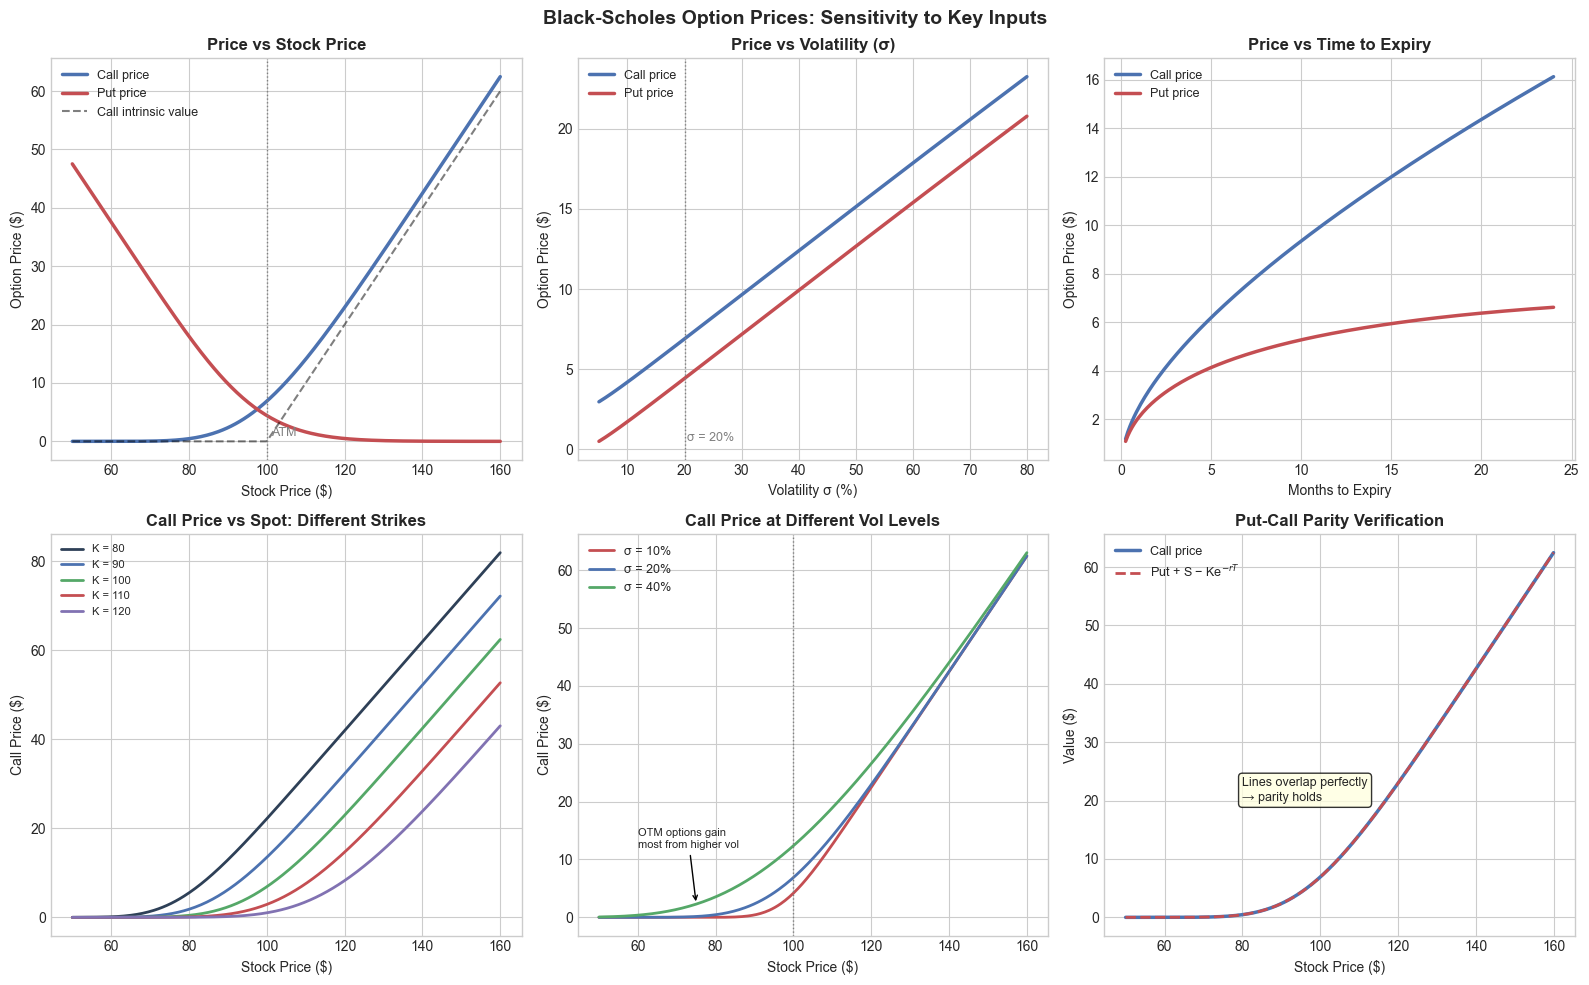

In [3]:
S_base = 100.0
K_base = 100.0
T_base = 0.5        # 6 months
r_base = 0.05
sigma_base = 0.20   # 20% vol

spot_range = np.linspace(50, 160, 300)
vol_range = np.linspace(0.05, 0.80, 200)
mat_range = np.linspace(0.02, 2.0, 200)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Black-Scholes Option Prices: Sensitivity to Key Inputs", fontsize=14, fontweight="bold")

# Row 1: Call price
# Panel 1: Price vs Spot
ax = axes[0, 0]
call_vs_spot = [bs_call(s, K_base, T_base, r_base, sigma_base) for s in spot_range]
put_vs_spot = [bs_put(s, K_base, T_base, r_base, sigma_base) for s in spot_range]
intrinsic_call = np.maximum(spot_range - K_base, 0)
ax.plot(spot_range, call_vs_spot, "#4C72B0", linewidth=2.5, label="Call price")
ax.plot(spot_range, put_vs_spot, "#C44E52", linewidth=2.5, label="Put price")
ax.plot(spot_range, intrinsic_call, "k--", linewidth=1.5, alpha=0.5, label="Call intrinsic value")
ax.axvline(K_base, color="grey", linewidth=1, linestyle=":")
ax.set_title("Price vs Stock Price", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Option Price ($)")
ax.legend(fontsize=9)
ax.text(K_base + 1, 1, "ATM", fontsize=9, color="grey")

# Panel 2: Price vs Volatility
ax = axes[0, 1]
call_vs_vol = [bs_call(S_base, K_base, T_base, r_base, v) for v in vol_range]
put_vs_vol = [bs_put(S_base, K_base, T_base, r_base, v) for v in vol_range]
ax.plot(vol_range * 100, call_vs_vol, "#4C72B0", linewidth=2.5, label="Call price")
ax.plot(vol_range * 100, put_vs_vol, "#C44E52", linewidth=2.5, label="Put price")
ax.axvline(sigma_base * 100, color="grey", linestyle=":", linewidth=1)
ax.set_title("Price vs Volatility (σ)", fontweight="bold")
ax.set_xlabel("Volatility σ (%)")
ax.set_ylabel("Option Price ($)")
ax.legend(fontsize=9)
ax.text(sigma_base * 100 + 0.5, 0.5, f"σ = {sigma_base*100:.0f}%", fontsize=9, color="grey")

# Panel 3: Price vs Time to Expiry
ax = axes[0, 2]
call_vs_T = [bs_call(S_base, K_base, t, r_base, sigma_base) for t in mat_range]
put_vs_T = [bs_put(S_base, K_base, t, r_base, sigma_base) for t in mat_range]
ax.plot(mat_range * 12, call_vs_T, "#4C72B0", linewidth=2.5, label="Call price")
ax.plot(mat_range * 12, put_vs_T, "#C44E52", linewidth=2.5, label="Put price")
ax.set_title("Price vs Time to Expiry", fontweight="bold")
ax.set_xlabel("Months to Expiry")
ax.set_ylabel("Option Price ($)")
ax.legend(fontsize=9)

# Row 2: Varying strike (moneyness)
ax = axes[1, 0]
strikes = [80, 90, 100, 110, 120]
colors_k = ["#2e4057", "#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for K_i, clr_i in zip(strikes, colors_k):
    c = [bs_call(s, K_i, T_base, r_base, sigma_base) for s in spot_range]
    ax.plot(spot_range, c, color=clr_i, linewidth=2, label=f"K = {K_i}")
ax.set_title("Call Price vs Spot: Different Strikes", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Call Price ($)")
ax.legend(fontsize=8)

# Panel 5: Effect of vol on strike profile (OTM options benefit most)
ax = axes[1, 1]
for sig, clr_s in [(0.10, "#C44E52"), (0.20, "#4C72B0"), (0.40, "#55A868")]:
    c = [bs_call(s, K_base, T_base, r_base, sig) for s in spot_range]
    ax.plot(spot_range, c, color=clr_s, linewidth=2, label=f"σ = {sig*100:.0f}%")
ax.axvline(K_base, color="grey", linestyle=":", linewidth=1)
ax.set_title("Call Price at Different Vol Levels", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Call Price ($)")
ax.legend(fontsize=9)
ax.annotate("OTM options gain\nmost from higher vol",
            xy=(75, bs_call(75, K_base, T_base, r_base, 0.40)),
            xytext=(60, 12), arrowprops=dict(arrowstyle="->"), fontsize=8)

# Panel 6: Put-call parity
ax = axes[1, 2]
pcp_lhs = np.array([bs_call(s, K_base, T_base, r_base, sigma_base) for s in spot_range])
pcp_rhs = np.array([bs_put(s, K_base, T_base, r_base, sigma_base) + s - K_base * np.exp(-r_base * T_base)
                    for s in spot_range])
ax.plot(spot_range, pcp_lhs, "#4C72B0", linewidth=2.5, label="Call price")
ax.plot(spot_range, pcp_rhs, "#C44E52", linewidth=2, linestyle="--", label=r"Put + S − Ke$^{-rT}$")
ax.set_title("Put-Call Parity Verification", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Value ($)")
ax.legend(fontsize=9)
ax.text(80, 20, "Lines overlap perfectly\n→ parity holds", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.show()

### How to read the Black-Scholes charts

**Panel 1 — Price vs Stock Price:**
Both call (blue) and put (red) curves show the option's market price at different stock prices. The dashed black line is the call's intrinsic value (what you'd get by exercising immediately). The smooth curve above it is the full option price — the gap between the curve and the dashed line is the **time value**. As the stock moves deep ITM, the time value shrinks and the option price converges to intrinsic value.

**Panel 2 — Price vs Volatility:**
Both call and put prices rise monotonically as volatility increases. This is because higher volatility means a wider distribution of possible future stock prices, increasing the chance of the option finishing deep ITM. Crucially, options are asymmetric — they only pay in one direction — so more vol always helps.

**Panel 3 — Price vs Time to Expiry:**
Both prices fall as expiry approaches (moving right to left = time is running out). This is **time decay** (theta). Near-zero time left → near-zero time value.

**Panel 4 — Different Strikes:**
Lower strike calls (K=80, dark blue) are more expensive because they are ITM — you're paying for guaranteed intrinsic value plus time value. Higher strike calls (K=120, purple) are cheap OTM options.

**Panel 5 — Effect of Volatility Level:**
At-the-money (near S=100), all three vol levels give similar prices. The big differences appear in the wings (OTM options). Higher vol inflates OTM option prices dramatically — this is why traders say "vol is expensive in OTM strikes."

**Panel 6 — Put-Call Parity:**
The two lines overlap perfectly. **Put-call parity** states: Call = Put + S − Ke^{−rT}. This is a no-arbitrage relationship — if it were violated, you could make a risk-free profit.

## 3. The Greeks — How Option Price Reacts to Market Changes

The **Greeks** measure how sensitive an option's price is to each input. They are the key risk management tools for options traders.

| Greek | Symbol | Measures | Units | Key use |
|---|---|---|---|---|
| **Delta** | Δ | Price change per $1 move in stock | $ per $ | Hedging direction |
| **Gamma** | Γ | Delta change per $1 move in stock | $ per $² | Hedging stability |
| **Vega** | ν | Price change per 1% move in vol | $ per % vol | Vol trading |
| **Theta** | Θ | Price change per 1 calendar day | $ per day | Time decay |
| **Rho** | ρ | Price change per 1% move in rates | $ per % | Rate sensitivity |

---

### 3.1 Delta (Δ) — "How much does price move?"

$$\Delta_{\text{call}} = N(d_1), \qquad \Delta_{\text{put}} = N(d_1) - 1$$

- Call delta is always between 0 and 1
- Put delta is always between −1 and 0
- ATM call has delta ≈ 0.5 (option gains $0.50 for every $1 stock rise)
- Deep ITM call has delta ≈ 1 (moves dollar-for-dollar with the stock)
- Deep OTM call has delta ≈ 0 (barely moves)

**Delta is also approximately the probability of the call expiring in-the-money** (under the risk-neutral measure).

**Delta hedging**: to create a delta-neutral position, buy 1 option and sell Δ shares. The combined portfolio doesn't move when the stock makes a small move.

---

### 3.2 Gamma (Γ) — "How fast does delta change?"

$$\Gamma = \frac{N'(d_1)}{S \sigma \sqrt{T}}$$

- Gamma is always positive for long options (calls and puts)
- Gamma is highest for ATM options near expiry
- High gamma = delta changes quickly → need to rehedge often
- Short gamma positions (option sellers) are hurt by large stock moves

---

### 3.3 Vega (ν) — "How much does price gain from more vol?"

$$\nu = S \cdot N'(d_1) \cdot \sqrt{T} \quad (\text{per 1\% change in } \sigma)$$

- Always positive for long options — more vol always helps the buyer
- Largest for ATM options and longer maturities
- A vega of $0.25 means: if vol rises from 20% to 21%, option gains $0.25

---

### 3.4 Theta (Θ) — "How much does the option lose each day?"

$$\Theta \approx -\frac{S \cdot N'(d_1) \cdot \sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2) \quad (\text{per year, divide by 365 for daily})$$

- Always negative for long options (you lose time value every day you hold)
- Largest for ATM options near expiry
- Theta and Gamma are closely linked: **high gamma = high theta** (you pay for the right to profit from moves, by losing time value daily)

---

### 3.5 The Gamma-Theta trade-off

This is the most important dynamic relationship in options:

> **Long gamma** (bought options) → you profit from large stock moves, but you lose theta every day.  
> **Short gamma** (sold options) → you collect theta every day, but you suffer losses from large stock moves.

Options trading is often framed as: *"Are you willing to pay theta to be long gamma?"*

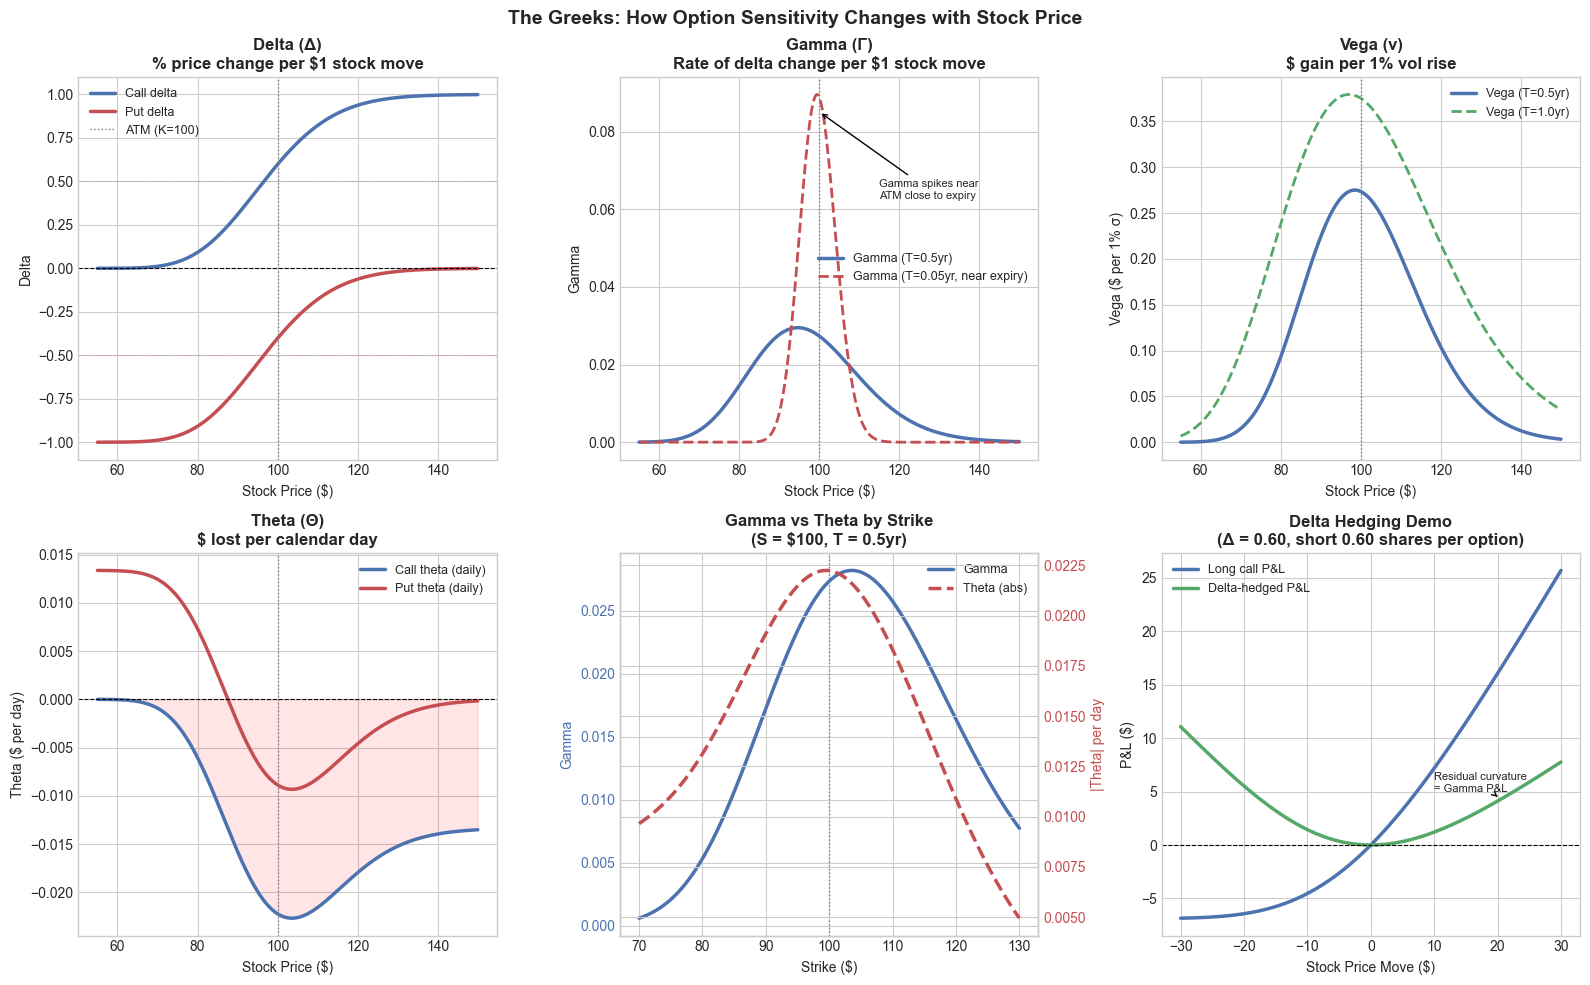

In [4]:
spot_g = np.linspace(55, 150, 300)
K_g, T_g, r_g = 100.0, 0.5, 0.05
sigma_g = 0.20

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("The Greeks: How Option Sensitivity Changes with Stock Price", fontsize=14, fontweight="bold")

# Delta
ax = axes[0, 0]
dc = [delta_call(s, K_g, T_g, r_g, sigma_g) for s in spot_g]
dp = [delta_put(s, K_g, T_g, r_g, sigma_g) for s in spot_g]
ax.plot(spot_g, dc, "#4C72B0", linewidth=2.5, label="Call delta")
ax.plot(spot_g, dp, "#C44E52", linewidth=2.5, label="Put delta")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axhline(0.5, color="#4C72B0", linewidth=0.8, linestyle=":", alpha=0.5)
ax.axhline(-0.5, color="#C44E52", linewidth=0.8, linestyle=":", alpha=0.5)
ax.axvline(K_g, color="grey", linewidth=1, linestyle=":", label="ATM (K=100)")
ax.set_title("Delta (Δ)\n% price change per $1 stock move", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Delta")
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9)

# Gamma
ax = axes[0, 1]
gm = [gamma(s, K_g, T_g, r_g, sigma_g) for s in spot_g]
gm_near = [gamma(s, K_g, 0.05, r_g, sigma_g) for s in spot_g]  # near expiry
ax.plot(spot_g, gm, "#4C72B0", linewidth=2.5, label="Gamma (T=0.5yr)")
ax.plot(spot_g, gm_near, "#C44E52", linewidth=2, linestyle="--", label="Gamma (T=0.05yr, near expiry)")
ax.axvline(K_g, color="grey", linewidth=1, linestyle=":")
ax.set_title("Gamma (Γ)\nRate of delta change per $1 stock move", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Gamma")
ax.legend(fontsize=9)
ax.annotate("Gamma spikes near\nATM close to expiry",
            xy=(K_g, max(gm_near) * 0.95), xytext=(115, max(gm_near) * 0.7),
            arrowprops=dict(arrowstyle="->"), fontsize=8)

# Vega
ax = axes[0, 2]
vg = [vega(s, K_g, T_g, r_g, sigma_g) for s in spot_g]
vg_long = [vega(s, K_g, 1.0, r_g, sigma_g) for s in spot_g]
ax.plot(spot_g, vg, "#4C72B0", linewidth=2.5, label="Vega (T=0.5yr)")
ax.plot(spot_g, vg_long, "#55A868", linewidth=2, linestyle="--", label="Vega (T=1.0yr)")
ax.axvline(K_g, color="grey", linewidth=1, linestyle=":")
ax.set_title("Vega (ν)\n$ gain per 1% vol rise", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Vega ($ per 1% σ)")
ax.legend(fontsize=9)

# Theta
ax = axes[1, 0]
th_c = [theta_call(s, K_g, T_g, r_g, sigma_g) for s in spot_g]
th_p = [theta_put(s, K_g, T_g, r_g, sigma_g) for s in spot_g]
ax.plot(spot_g, th_c, "#4C72B0", linewidth=2.5, label="Call theta (daily)")
ax.plot(spot_g, th_p, "#C44E52", linewidth=2.5, label="Put theta (daily)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(K_g, color="grey", linewidth=1, linestyle=":")
ax.set_title("Theta (Θ)\n$ lost per calendar day", fontweight="bold")
ax.set_xlabel("Stock Price ($)")
ax.set_ylabel("Theta ($ per day)")
ax.legend(fontsize=9)
ax.fill_between(spot_g, th_c, 0, alpha=0.1, color="red")

# Gamma-Theta trade-off
ax = axes[1, 1]
strikes_gt = np.linspace(70, 130, 100)
gm_atm = [gamma(S_base, k, T_g, r_g, sigma_g) for k in strikes_gt]
th_atm = [abs(theta_call(S_base, k, T_g, r_g, sigma_g)) for k in strikes_gt]
ax2_twin = ax.twinx()
ax.plot(strikes_gt, gm_atm, "#4C72B0", linewidth=2.5, label="Gamma")
ax2_twin.plot(strikes_gt, th_atm, "#C44E52", linewidth=2.5, linestyle="--", label="Theta (abs)")
ax.set_title("Gamma vs Theta by Strike\n(S = $100, T = 0.5yr)", fontweight="bold")
ax.set_xlabel("Strike ($)")
ax.set_ylabel("Gamma", color="#4C72B0")
ax2_twin.set_ylabel("|Theta| per day", color="#C44E52")
ax.tick_params(axis="y", labelcolor="#4C72B0")
ax2_twin.tick_params(axis="y", labelcolor="#C44E52")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.axvline(S_base, color="grey", linewidth=1, linestyle=":")

# Delta hedging demo: portfolio value vs stock move
ax = axes[1, 2]
stock_moves = np.linspace(-30, 30, 300)
S_shocked = S_base + stock_moves
call_shocked = np.array([bs_call(s, K_g, T_g, r_g, sigma_g) for s in S_shocked])
call_base_val = bs_call(S_base, K_g, T_g, r_g, sigma_g)
d_base = delta_call(S_base, K_g, T_g, r_g, sigma_g)
unhedged_pnl = call_shocked - call_base_val
hedged_pnl = unhedged_pnl - d_base * stock_moves  # delta-hedged book
ax.plot(stock_moves, unhedged_pnl, "#4C72B0", linewidth=2.5, label="Long call P&L")
ax.plot(stock_moves, hedged_pnl, "#55A868", linewidth=2.5, label="Delta-hedged P&L")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Delta Hedging Demo\n(Δ = {d_base:.2f}, short {d_base:.2f} shares per option)", fontweight="bold")
ax.set_xlabel("Stock Price Move ($)")
ax.set_ylabel("P&L ($)")
ax.legend(fontsize=9)
ax.annotate("Residual curvature\n= Gamma P&L",
            xy=(20, hedged_pnl[int(len(hedged_pnl)*0.85)]),
            xytext=(10, 5), arrowprops=dict(arrowstyle="->"), fontsize=8)

plt.tight_layout()
plt.show()

### How to read the Greeks charts

**Delta (top-left):**
Call delta rises from 0 (far OTM, stock = $55) to 1 (deep ITM, stock = $150). Put delta mirrors this from −1 to 0. The ATM point is where both cross ±0.5. If you own a call with delta = 0.6, your position gains $0.60 for every $1 the stock rises.

**Gamma (top-middle):**
Gamma peaks at-the-money and falls sharply in both directions. The near-expiry line (red dashed) is far taller and narrower — near expiry, delta changes explosively around the strike. This is the "pin risk" traders worry about when expiry approaches near the strike.

**Vega (top-right):**
Vega also peaks ATM and is larger for longer-dated options (green dashed, T=1yr > T=0.5yr). A long-dated ATM option has more time for volatility to have an effect, so its price is more sensitive to vol changes.

**Theta (bottom-left):**
Theta is always negative for long options. The largest daily decay happens ATM — you pay the most time value there, and it bleeds fastest. Deep ITM and OTM options have less theta. If you hold a long option over a weekend (3 days), theta accrues roughly 3× the daily value.

**Gamma vs Theta (bottom-middle):**
Both gamma and |theta| peak at the same strike (ATM). They are inseparable twins: you cannot be long gamma without also being short theta. The ratio of gamma to theta is roughly constant across strikes — there is no "free lunch" of gamma without paying theta.

**Delta hedging (bottom-right):**
The blue curve shows unhedged P&L — it curves upward (convex) because gamma gives you positive P&L for large moves in either direction. The green curve shows a delta-hedged book — it removes the linear component, leaving only the curvature (gamma P&L). The residual upward bow is pure gamma profit. This is why traders say long gamma positions benefit from realised volatility.

## 4. Volatility — The Heart of Options Pricing

### 4.1 What is volatility?

**Volatility** (σ) measures how much a stock's price moves. More precisely, it is the **annualised standard deviation of log-returns**.

$$\sigma = \sqrt{\frac{252}{n-1} \sum_{i=1}^{n} (r_i - \bar{r})^2}, \qquad r_i = \ln\!\left(\frac{S_i}{S_{i-1}}\right)$$

A stock with σ = 20% moves, on average, ±20% per year. For daily moves, divide by $\sqrt{252} \approx 16$: a 20% vol stock moves about ±1.25% per day on average.

---

### 4.2 Historical volatility vs Implied volatility

| Type | How it's computed | What it represents |
|---|---|---|
| **Historical vol (HV)** | Calculated from past stock returns | How much the stock *has* moved |
| **Implied vol (IV)** | Backed out from market option prices | How much the market *expects* the stock to move |

**Implied volatility is the market's forecast.** When you buy an option at a certain price, you are implicitly agreeing with the market's view of future vol. If you think realised vol will be *higher* than implied vol, you should buy options (long vega). If lower, sell them (short vega).

---

### 4.3 The vol risk premium

Historically, implied vol tends to trade *above* realised (historical) vol. The average difference is the **volatility risk premium** — compensation to option sellers for taking on the risk of unexpectedly large moves.

This means:
- Selling options (short vol) has historically been profitable on average
- But option sellers face occasional large losses (during crashes, spikes)

---

### 4.4 VIX — the "fear gauge"

The **VIX** is the implied volatility of 30-day S&P 500 options. When markets are calm: VIX ≈ 12−15%. When markets are stressed (2008 crisis, COVID crash): VIX > 60−80%.

**VIX and stock market direction are negatively correlated:** when stocks fall, fear spikes and VIX rises. This makes long volatility a natural hedge for equity portfolios.

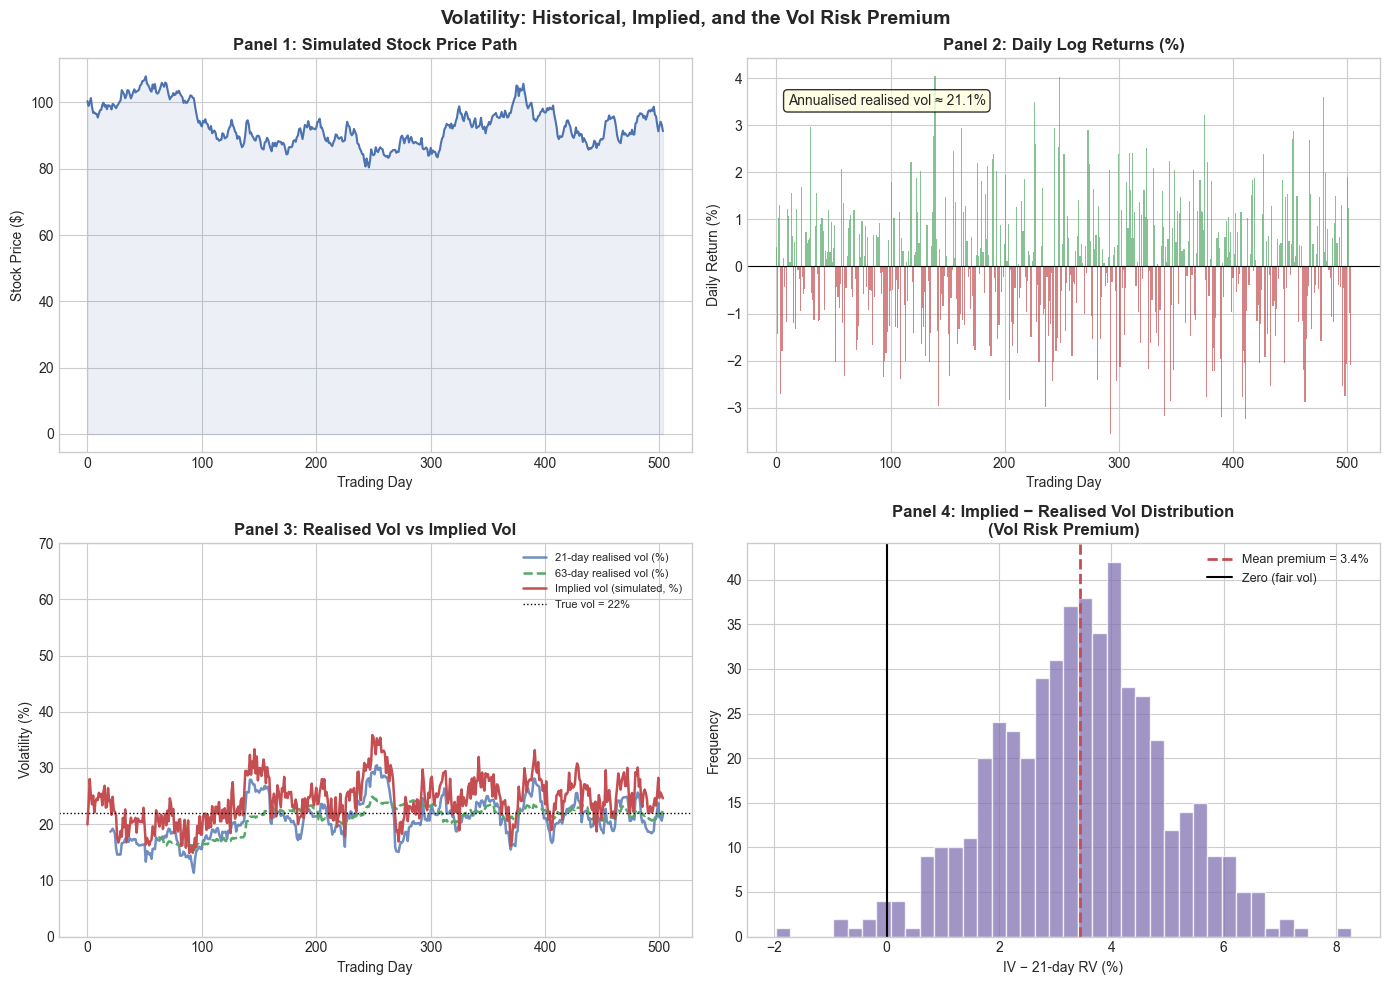

In [5]:
# ── Simulate a stock price series for historical vol demonstration ─────────────
n_days = 504   # 2 years
annual_vol_true = 0.22
daily_vol = annual_vol_true / np.sqrt(252)
log_returns = RNG.normal(0, daily_vol, n_days)
stock_prices = 100 * np.exp(np.cumsum(log_returns))
trading_days = np.arange(n_days)

# Rolling historical vol (21-day and 63-day)
window_21 = 21
window_63 = 63
hv21 = pd.Series(log_returns).rolling(window_21).std() * np.sqrt(252) * 100
hv63 = pd.Series(log_returns).rolling(window_63).std() * np.sqrt(252) * 100

# Simulated implied vol (HV + a random premium + some mean-reversion)
iv_premium = 3.5   # average vol risk premium in %
iv_simulated = hv21.fillna(hv21.mean()) + iv_premium + RNG.normal(0, 1.5, n_days)
iv_simulated = pd.Series(np.clip(iv_simulated, 5, 80))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Volatility: Historical, Implied, and the Vol Risk Premium", fontsize=14, fontweight="bold")

# Panel 1: Stock price
ax = axes[0, 0]
ax.plot(trading_days, stock_prices, color="#4C72B0", linewidth=1.5)
ax.set_title("Panel 1: Simulated Stock Price Path", fontweight="bold")
ax.set_xlabel("Trading Day")
ax.set_ylabel("Stock Price ($)")
ax.fill_between(trading_days, stock_prices, alpha=0.1, color="#4C72B0")

# Panel 2: Log returns
ax = axes[0, 1]
ax.bar(trading_days, log_returns * 100, color=np.where(log_returns >= 0, "#55A868", "#C44E52"), 
       alpha=0.7, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Panel 2: Daily Log Returns (%)", fontweight="bold")
ax.set_xlabel("Trading Day")
ax.set_ylabel("Daily Return (%)")
ax.text(10, max(log_returns * 100) * 0.85,
        f"Annualised realised vol ≈ {log_returns.std() * np.sqrt(252) * 100:.1f}%",
        fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

# Panel 3: Rolling historical vol vs implied vol
ax = axes[1, 0]
ax.plot(trading_days, hv21, "#4C72B0", linewidth=1.8, label="21-day realised vol (%)", alpha=0.8)
ax.plot(trading_days, hv63, "#55A868", linewidth=1.8, linestyle="--", label="63-day realised vol (%)")
ax.plot(trading_days, iv_simulated, "#C44E52", linewidth=1.8, label="Implied vol (simulated, %)")
ax.axhline(annual_vol_true * 100, color="black", linewidth=1, linestyle=":", label=f"True vol = {annual_vol_true*100:.0f}%")
ax.set_title("Panel 3: Realised Vol vs Implied Vol", fontweight="bold")
ax.set_xlabel("Trading Day")
ax.set_ylabel("Volatility (%)")
ax.legend(fontsize=8)
ax.set_ylim(0, 70)

# Panel 4: Vol risk premium distribution
ax = axes[1, 1]
vol_premium = iv_simulated - hv21.fillna(hv21.mean())
ax.hist(vol_premium, bins=40, color="#8172B2", alpha=0.75, edgecolor="white")
ax.axvline(vol_premium.mean(), color="#C44E52", linewidth=2, linestyle="--",
           label=f"Mean premium = {vol_premium.mean():.1f}%")
ax.axvline(0, color="black", linewidth=1.5, linestyle="-", label="Zero (fair vol)")
ax.set_title("Panel 4: Implied − Realised Vol Distribution\n(Vol Risk Premium)", fontweight="bold")
ax.set_xlabel("IV − 21-day RV (%)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### How to read the volatility charts

**Panel 1 — Stock price path:** A simulated 2-year stock path with 22% annual vol. Notice how the stock drifts and fluctuates — this randomness is what vol captures.

**Panel 2 — Daily log returns:** Green bars = up days, red bars = down days. Returns look like a roughly symmetric cloud around zero. The annualised standard deviation of these daily bars = historical volatility. Notice rare large bars on either side — these are the "fat tails" that Black-Scholes underweights.

**Panel 3 — Realised vs Implied vol:**
- Blue (21-day HV): bounces around quickly — reacts to recent moves
- Green (63-day HV): smoother — averages over a longer window
- Red (IV): tracks roughly above the realised vol lines — this is the **vol risk premium**
- Dashed black line: the "true" underlying vol used to simulate the data

**Panel 4 — Vol risk premium distribution:**
The histogram shows (Implied vol − 21-day realised vol) each day. The distribution is centred *above* zero (red dashed mean line to the right of zero), confirming that IV is systematically higher than realised vol on average. This is why systematic option selling strategies (short vol) tend to collect positive average returns — but occasionally suffer large drawdowns.

## 5. The Volatility Smile and Skew

### 5.1 What Black-Scholes predicts vs what markets show

The Black-Scholes model assumes **volatility is constant** across all strikes and maturities. If this were true, you could use the same σ to price every option on the same stock — and implied vols backed out from all market prices would be flat.

In practice, they are **not flat**. When you back out the implied vol from market prices at different strikes, you get a curve called the **volatility smile** (or **skew**).

---

### 5.2 The volatility smile

For equity options, the vol surface typically shows:

- **Higher implied vol for OTM puts (low strikes)**: investors pay a premium for downside protection (crash risk)
- **Lower implied vol for ATM options**: the "fair" middle
- **Slightly higher implied vol for OTM calls (high strikes)**: demand for upside participation

This creates a shape that looks like a **smirk or left-skewed smile** for equity indices.

---

### 5.3 Why does the smile/skew exist?

Black-Scholes assumes log-normal returns. Real stock returns have:

| Real feature | Effect on options |
|---|---|
| **Negative skew** | Stocks crash more violently than they rally → OTM puts are "too cheap" under flat-vol BS → market bids them up → left-skew in IV |
| **Fat tails (excess kurtosis)** | Large moves happen more often than log-normal predicts → OTM puts AND calls are bid up → symmetric smile wings |
| **Jump risk** | Earnings, macroeconomic events cause gap moves → OTM options priced for gap risk |
| **Supply/demand** | Hedgers systematically buy puts for portfolio protection → put demand pushes up put IV |

---

### 5.4 The volatility term structure

Implied vol also varies across maturities. Typically:
- **Short-dated IV is more volatile** — reacts sharply to near-term events (earnings, central bank meetings)
- **Long-dated IV is more stable** — reflects long-run uncertainty
- **Normal shape**: short-dated IV < long-dated IV (forward vol is priced in)
- **Inverted shape**: short-dated IV > long-dated IV (current stress is expected to calm down)

---

### 5.5 The implied volatility surface

The full picture is a **2D surface**: implied vol as a function of both strike and maturity.

$$\sigma_{\text{impl}} = f(K, T)$$

Traders and quants model this surface to:
- Price exotic options consistently with the market
- Identify cheap or expensive options relative to the surface
- Risk manage portfolios under consistent vol assumptions

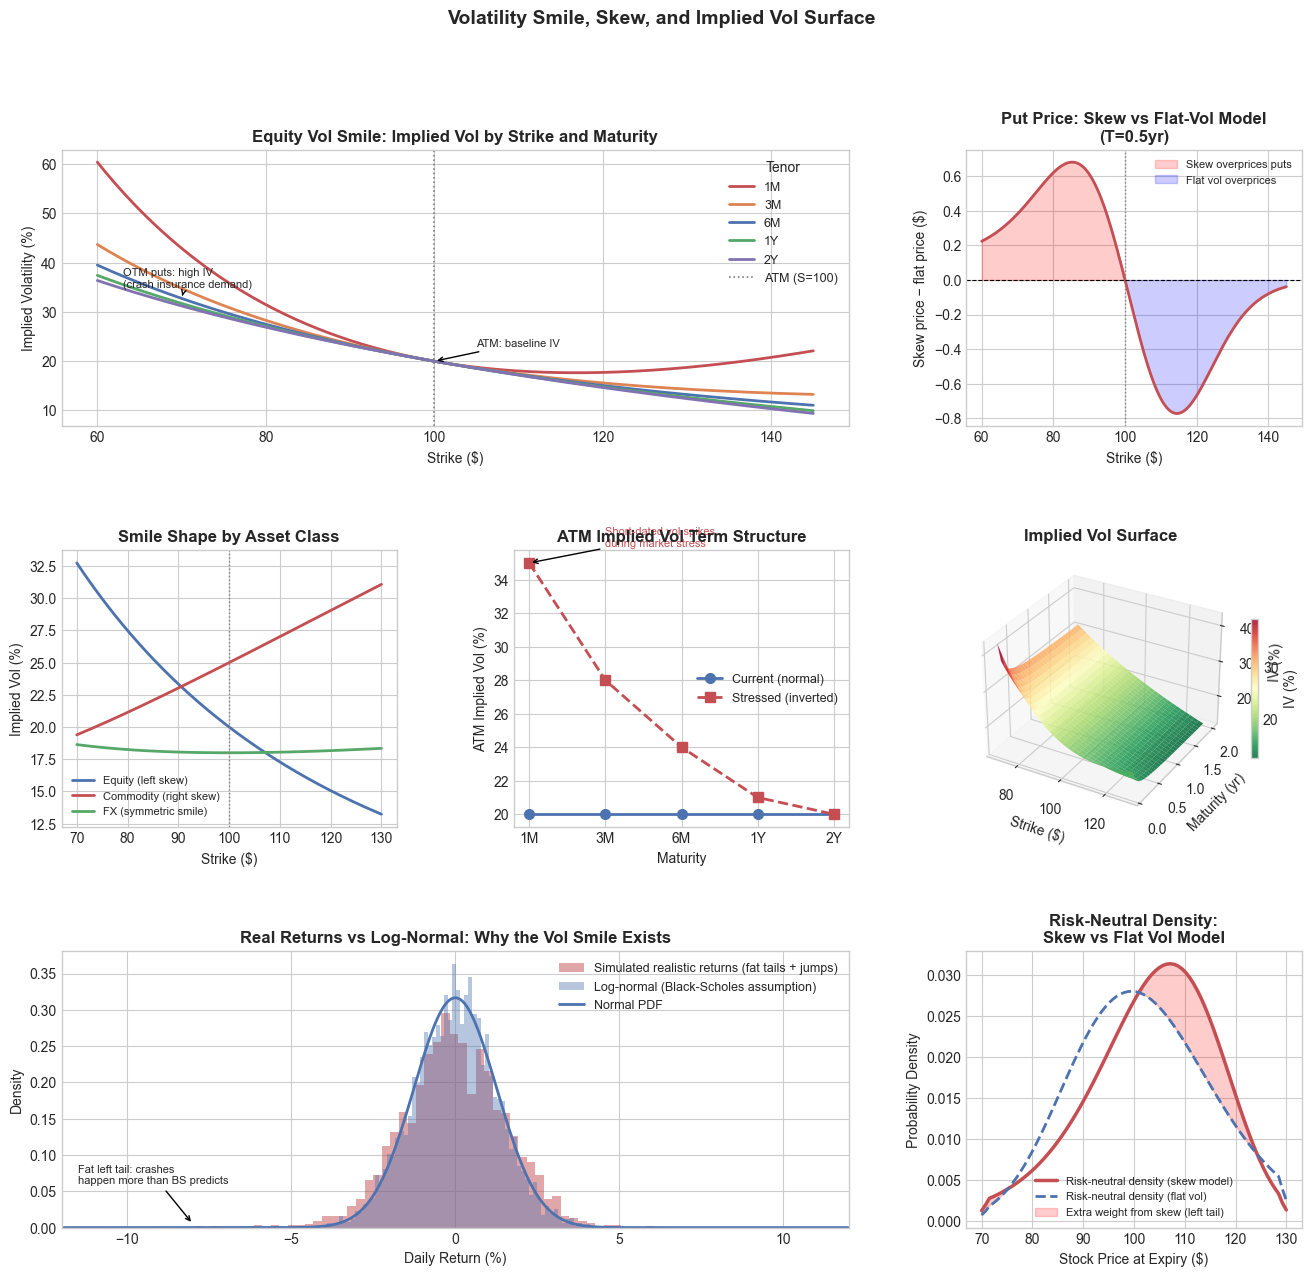

In [6]:
S_smile = 100.0
r_smile = 0.05
T_smile_atm = 0.5

# ── Simulate a realistic vol smile/skew for equity ────────────────────────────
# Equity skew: OTM puts expensive, OTM calls slightly elevated
def equity_smile(K, T, S=100, atm_vol=0.20, skew_slope=-0.30, wing_curvature=0.08):
    """Parametric equity vol skew: left skew + symmetric wings."""
    log_moneyness = np.log(K / S) / np.sqrt(T)   # normalised by sqrt(T)
    return atm_vol + skew_slope * log_moneyness * np.sqrt(T) + wing_curvature * log_moneyness**2

strikes = np.linspace(60, 145, 200)
tenors = [1/12, 3/12, 6/12, 1.0, 2.0]   # 1M, 3M, 6M, 1Y, 2Y
tenor_labels = ["1M", "3M", "6M", "1Y", "2Y"]
colors_t = ["#C44E52", "#DD8452", "#4C72B0", "#55A868", "#8172B2"]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("Volatility Smile, Skew, and Implied Vol Surface", fontsize=14, fontweight="bold")

# Panel 1: Vol smile for multiple tenors
ax1 = fig.add_subplot(gs[0, :2])
for T_i, lbl, clr in zip(tenors, tenor_labels, colors_t):
    iv_smile = equity_smile(strikes, T_i) * 100
    ax1.plot(strikes, iv_smile, color=clr, linewidth=2, label=lbl)
ax1.axvline(S_smile, color="grey", linewidth=1.2, linestyle=":", label="ATM (S=100)")
ax1.set_title("Equity Vol Smile: Implied Vol by Strike and Maturity", fontweight="bold")
ax1.set_xlabel("Strike ($)")
ax1.set_ylabel("Implied Volatility (%)")
ax1.legend(fontsize=9, title="Tenor")
ax1.annotate("OTM puts: high IV\n(crash insurance demand)",
             xy=(70, equity_smile(70, 0.5) * 100),
             xytext=(63, 35), arrowprops=dict(arrowstyle="->"), fontsize=8)
ax1.annotate("ATM: baseline IV",
             xy=(S_smile, equity_smile(S_smile, 0.5) * 100),
             xytext=(105, 23), arrowprops=dict(arrowstyle="->"), fontsize=8)

# Panel 2: Flat vol (BS) vs skew — price differences
ax2 = fig.add_subplot(gs[0, 2])
flat_vol = 0.20
T_cmp = 0.5
iv_skew_cmp = equity_smile(strikes, T_cmp)
price_skew = np.array([bs_put(S_smile, k, T_cmp, r_smile, max(equity_smile(k, T_cmp), 0.01)) for k in strikes])
price_flat = np.array([bs_put(S_smile, k, T_cmp, r_smile, flat_vol) for k in strikes])
ax2.plot(strikes, price_skew - price_flat, "#C44E52", linewidth=2)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.axvline(S_smile, color="grey", linewidth=1, linestyle=":")
ax2.fill_between(strikes, price_skew - price_flat, 0,
                 where=(price_skew > price_flat), alpha=0.2, color="red", label="Skew overprices puts")
ax2.fill_between(strikes, price_skew - price_flat, 0,
                 where=(price_skew < price_flat), alpha=0.2, color="blue", label="Flat vol overprices")
ax2.set_title("Put Price: Skew vs Flat-Vol Model\n(T=0.5yr)", fontweight="bold")
ax2.set_xlabel("Strike ($)")
ax2.set_ylabel("Skew price − flat price ($)")
ax2.legend(fontsize=8)

# Panel 3: Skew slope comparison — equity (negative skew) vs commodity (positive skew)
ax3 = fig.add_subplot(gs[1, 0])
def commodity_smile(K, T, S=100, atm_vol=0.25, skew_slope=0.20, wing_curvature=0.06):
    log_moneyness = np.log(K / S) / np.sqrt(T)
    return atm_vol + skew_slope * log_moneyness * np.sqrt(T) + wing_curvature * log_moneyness**2

strikes_mid = np.linspace(70, 130, 200)
iv_equity = equity_smile(strikes_mid, 0.5) * 100
iv_commodity = commodity_smile(strikes_mid, 0.5) * 100
iv_fx = (0.18 + 0.05 * (np.log(strikes_mid / 100))**2) * 100  # symmetric FX smile

ax3.plot(strikes_mid, iv_equity, "#4C72B0", linewidth=2, label="Equity (left skew)")
ax3.plot(strikes_mid, iv_commodity, "#C44E52", linewidth=2, label="Commodity (right skew)")
ax3.plot(strikes_mid, iv_fx, "#55A868", linewidth=2, label="FX (symmetric smile)")
ax3.axvline(100, color="grey", linewidth=1, linestyle=":")
ax3.set_title("Smile Shape by Asset Class", fontweight="bold")
ax3.set_xlabel("Strike ($)")
ax3.set_ylabel("Implied Vol (%)")
ax3.legend(fontsize=8)

# Panel 4: Vol term structure at ATM
ax4 = fig.add_subplot(gs[1, 1])
atm_iv_by_tenor = [equity_smile(S_smile, t) * 100 for t in tenors]
# Inverted + normal term structure examples
atm_normal = [16, 18, 20, 21, 22]
atm_inverted = [35, 28, 24, 21, 20]
ax4.plot(tenor_labels, atm_iv_by_tenor, "#4C72B0", marker="o", linewidth=2, markersize=7, label="Current (normal)")
ax4.plot(tenor_labels, atm_inverted, "#C44E52", marker="s", linewidth=2, linestyle="--", markersize=7, label="Stressed (inverted)")
ax4.set_title("ATM Implied Vol Term Structure", fontweight="bold")
ax4.set_xlabel("Maturity")
ax4.set_ylabel("ATM Implied Vol (%)")
ax4.legend(fontsize=9)
ax4.annotate("Short-dated vol spikes\nduring market stress", xy=("1M", 35),
             xytext=("3M", 36), arrowprops=dict(arrowstyle="->"), fontsize=8, color="#C44E52")

# Panel 5: Implied vol surface (3D)
ax5 = fig.add_subplot(gs[1, 2], projection="3d")
K_mesh = np.linspace(70, 130, 30)
T_mesh = np.linspace(1/12, 2.0, 30)
K_grid, T_grid = np.meshgrid(K_mesh, T_mesh)
IV_grid = equity_smile(K_grid, T_grid) * 100
surf = ax5.plot_surface(K_grid, T_grid, IV_grid, cmap="RdYlGn_r", alpha=0.85)
ax5.set_title("Implied Vol Surface", fontweight="bold", pad=10)
ax5.set_xlabel("Strike ($)")
ax5.set_ylabel("Maturity (yr)")
ax5.set_zlabel("IV (%)")
fig.colorbar(surf, ax=ax5, shrink=0.5, label="IV (%)")

# Panel 6: Real vs BS return distribution comparison
ax6 = fig.add_subplot(gs[2, :2])
sigma_bs = 0.20
daily_ret_bs = RNG.normal(0, sigma_bs / np.sqrt(252), 5000)
# Simulate "fat-tailed" returns with occasional jumps
daily_ret_real = RNG.normal(0, 0.015, 5000)
jump_mask = RNG.random(5000) < 0.015   # 1.5% chance of a jump per day
daily_ret_real[jump_mask] += RNG.normal(-0.04, 0.04, jump_mask.sum())

x_range = np.linspace(-0.12, 0.12, 300)
from scipy.stats import norm as sp_norm
bs_pdf = sp_norm.pdf(x_range, 0, sigma_bs / np.sqrt(252))

ax6.hist(daily_ret_real * 100, bins=80, density=True, alpha=0.5, color="#C44E52", label="Simulated realistic returns (fat tails + jumps)")
ax6.hist(daily_ret_bs * 100, bins=80, density=True, alpha=0.4, color="#4C72B0", label="Log-normal (Black-Scholes assumption)")
ax6.plot(x_range * 100, bs_pdf / 100, "#4C72B0", linewidth=2, label="Normal PDF")
ax6.set_xlim(-12, 12)
ax6.set_title("Real Returns vs Log-Normal: Why the Vol Smile Exists", fontweight="bold")
ax6.set_xlabel("Daily Return (%)")
ax6.set_ylabel("Density")
ax6.legend(fontsize=9)
ax6.annotate("Fat left tail: crashes\nhappen more than BS predicts",
             xy=(-8, 0.005), xytext=(-11.5, 0.06),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=8)

# Panel 7: Smile and risk-neutral distribution
ax7 = fig.add_subplot(gs[2, 2])
# Breeden-Litzenberger: risk-neutral density from call prices
K_rn = np.linspace(70, 130, 80)
dK = K_rn[1] - K_rn[0]
call_prices = np.array([bs_call(S_smile, k, T_smile_atm, r_smile, equity_smile(k, T_smile_atm)) for k in K_rn])
rnd = np.exp(r_smile * T_smile_atm) * np.gradient(np.gradient(call_prices, dK), dK)
rnd_normal = np.exp(r_smile * T_smile_atm) * np.gradient(np.gradient(
    np.array([bs_call(S_smile, k, T_smile_atm, r_smile, flat_vol) for k in K_rn]), dK), dK)

ax7.plot(K_rn, rnd, "#C44E52", linewidth=2.5, label="Risk-neutral density (skew model)")
ax7.plot(K_rn, rnd_normal, "#4C72B0", linewidth=2, linestyle="--", label="Risk-neutral density (flat vol)")
ax7.fill_between(K_rn, rnd, rnd_normal, where=(rnd > rnd_normal), alpha=0.2, color="red",
                 label="Extra weight from skew (left tail)")
ax7.set_title("Risk-Neutral Density:\nSkew vs Flat Vol Model", fontweight="bold")
ax7.set_xlabel("Stock Price at Expiry ($)")
ax7.set_ylabel("Probability Density")
ax7.legend(fontsize=8)

plt.show()

### How to read the volatility smile charts

**Panel 1 — Vol smile across maturities:**
Each line is a maturity. The x-axis is the strike price; the y-axis is implied vol. All lines slope downward from left to right — this is the **equity skew**: lower strikes (puts) have higher implied vol than higher strikes (calls). Short-dated lines (1M, red) have steeper slopes — near-term crash risk is priced more sharply. Longer-dated options (2Y, purple) show a flatter smile.

**Panel 2 — Skew vs flat-vol mispricing:**
This shows how much a flat-vol model (same σ = 20% everywhere) over- or underprices puts relative to the skew model. OTM puts (left of $100) are underpriced by flat vol — the skew model prices them higher to reflect crash demand.

**Panel 3 — Smile shape by asset class:**
- **Equity (blue)**: left skew — OTM puts expensive (crash demand)
- **Commodity (red)**: right skew — OTM calls expensive (supply shocks cause sharp price spikes)
- **FX (green)**: symmetric smile — currency risk is two-sided

**Panel 4 — Vol term structure:**
ATM vol at each maturity. Normal (blue) slopes upward — longer uncertainty commands higher vol. Inverted (red dashed) can occur during a market crisis when short-dated vol spikes above long-dated vol.

**Panel 5 — Implied vol surface (3D):**
The full surface. Strike on x-axis, maturity on y-axis, implied vol on z-axis. The left-skew (low strikes = high vol) runs through every maturity slice. The surface flattens at longer maturities — vol mean-reverts over time.

**Panel 6 — Real vs log-normal returns:**
The fat tails and leftward asymmetry of real returns (red histogram) vs the symmetric normal distribution BS assumes (blue). The extra mass in the left tail is exactly what OTM put buyers are paying for — and why put IV is elevated.

**Panel 7 — Risk-neutral density:**
The market's implied probability distribution of where the stock will be at expiry, extracted from option prices (Breeden-Litzenberger formula). The skew model (red) assigns more probability to lower prices than the flat-vol model (blue dashed) — reflecting the market's concern about downside scenarios.

## Main Takeaways

### Core rules to remember

1. **An option gives you the right, not the obligation.** The buyer has the choice. The seller has the obligation. The buyer pays a premium for that asymmetry.

2. **Option price = intrinsic value + time value.** Intrinsic value is what you'd get exercising today. Time value is the extra amount you pay for the chance the option moves further ITM before expiry.

3. **Five inputs drive Black-Scholes price: S, K, T, r, σ.** Of these, volatility is the most important and the only one that must be estimated. Everything else is observable.

4. **Price and volatility move together.** More uncertainty (higher σ) → more expensive options. This is always true for both calls and puts.

5. **The Greeks tell you how to hedge.** Delta neutralise the directional exposure. Gamma tells you how often you'll need to rehedge. Vega tells you your vol exposure.

6. **Gamma and theta are two sides of the same coin.** Long options = long gamma (profit from big moves) + short theta (pay time decay daily). Short options = the opposite.

7. **Implied vol is the market's forecast.** Compare it to your own view of realised vol. If you think actual moves will be bigger: buy options. If smaller: sell options.

8. **The vol smile exists because real returns are not log-normal.** Stocks crash more violently than they rally, and extreme moves happen more often than the normal distribution predicts. OTM puts are the most affected.

---

### Beginner checklist — can you answer these?

- [ ] A stock is at $100 and you buy a $105 call for $3. What is your maximum loss? What is the breakeven stock price at expiry?
- [ ] Why does an ATM option have a delta of approximately 0.5?
- [ ] If implied vol rises from 20% to 25% and your option has a vega of $0.30, how much does the option price change?
- [ ] Theta is −$0.04/day and you hold an option over a 3-day weekend. How much value do you lose?
- [ ] Why do OTM equity put options trade at higher implied vol than OTM calls?
- [ ] What does it mean to be "long gamma, short theta"?
- [ ] If the vol surface shows a steep left skew, what does the market believe about future stock returns?

---

### Topics to explore next

- **Stochastic volatility models (Heston, SABR)**: extend Black-Scholes to allow vol to be random — produces realistic smile shapes
- **Local volatility (Dupire)**: build a vol surface that exactly fits all market prices; vol is a deterministic function of S and T
- **Jump-diffusion models**: add discrete jumps to stock price process to capture fat tails
- **Variance swaps and volatility products**: trade volatility directly as an asset class
- **Options strategies**: spreads, straddles, strangles, butterflies — combining options to create specific payoff profiles
- **American options**: early exercise — requires binomial trees or PDE methods